# Preprocessing Data Notebook

This notebook processes the dataset:

`raws/Scats Data October 2006.xls`

It creates one processed file:

`processed/traffic_direction_timeseries.csv`


## 1. Import libraries and set paths


In [76]:
from pathlib import Path
import pandas as pd
import numpy as np

# Notebook is expected to be inside the data/ folder.
DATA_DIR = Path.cwd()
RAW_DIR = DATA_DIR / "raws"
PROCESSED_DIR = DATA_DIR / "processed"

RAW_FILE = RAW_DIR / "Scats Data October 2006.xls"
OUTPUT_FILE = PROCESSED_DIR / "traffic_direction_timeseries.csv"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Data folder:", DATA_DIR)
print("Raw folder:", RAW_DIR)
print("Processed folder:", PROCESSED_DIR)
print("Raw file:", RAW_FILE)
print("Output file:", OUTPUT_FILE)

if not RAW_FILE.exists():
    raise FileNotFoundError(f"Raw file not found: {RAW_FILE}")

Data folder: /Users/truonghuuminhhai/Documents/COS30019/Assignment2B/cos30019_assignment2_b/data
Raw folder: /Users/truonghuuminhhai/Documents/COS30019/Assignment2B/cos30019_assignment2_b/data/raws
Processed folder: /Users/truonghuuminhhai/Documents/COS30019/Assignment2B/cos30019_assignment2_b/data/processed
Raw file: /Users/truonghuuminhhai/Documents/COS30019/Assignment2B/cos30019_assignment2_b/data/raws/Scats Data October 2006.xls
Output file: /Users/truonghuuminhhai/Documents/COS30019/Assignment2B/cos30019_assignment2_b/data/processed/traffic_direction_timeseries.csv


## 2. Choose Excel reading engine

The raw file is `.xls`. Pandas may need either `python-calamine` or `xlrd`

Install at least one of these in your environment:

```bash
pip install python-calamine
```

or

```bash
pip install xlrd==2.0.1
```


In [77]:
def choose_excel_engine():
    """Use calamine if available, otherwise fall back to xlrd."""
    try:
        import python_calamine
        return "calamine"
    except ModuleNotFoundError:
        pass

    try:
        import xlrd
        return "xlrd"
    except ModuleNotFoundError:
        pass

    raise ImportError(
        "Install one of these first: pip install python-calamine OR pip install xlrd==2.0.1"
    )

EXCEL_ENGINE = choose_excel_engine()
print("Using Excel engine:", EXCEL_ENGINE)

Using Excel engine: calamine


## 3. Read the raw SCATS traffic flow file


In [78]:
xls = pd.ExcelFile(RAW_FILE, engine=EXCEL_ENGINE)

print("Available sheets:")
print(xls.sheet_names)

traffic_raw = pd.read_excel(
    RAW_FILE,
    sheet_name="Data",
    header=1,
    engine=EXCEL_ENGINE
)

print("Raw traffic shape:", traffic_raw.shape)
display(traffic_raw.head())

Available sheets:
['Notes', 'Data', 'Summary Of Data']
Raw traffic shape: (4192, 106)


,SCATS Number,Location,CD_MELWAY,NB_LATITUDE,NB_LONGITUDE,HF VicRoads Internal,VR Internal Stat,VR Internal Loc,NB_TYPE_SURVEY,Date,...,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95
0,970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-01 00:15:00,...,114,97,97,66,81,50,59,47,29,34
1,970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-02 00:15:00,...,111,102,107,114,80,60,62,48,44,26
2,970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-03 00:15:00,...,130,132,114,86,93,90,73,57,29,40
3,970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-04 00:15:00,...,115,113,132,101,113,90,78,66,52,44
4,970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-05 00:15:00,...,171,120,116,113,99,91,61,55,49,36


## 4. Clean column names

Column names are standardised to lowercase snake_case so the rest of the code is easier to use.


In [79]:
def clean_column_name(col):
    return (
        str(col)
        .strip()
        .lower()
        .replace("\n", " ")
        .replace("/", "_")
        .replace("-", "_")
        .replace("(", "")
        .replace(")", "")
        .replace(".", "")
        .replace(" ", "_")
    )

traffic = traffic_raw.copy()
traffic.columns = [clean_column_name(col) for col in traffic.columns]

print("Cleaned columns:")
print(traffic.columns.tolist())

display(traffic.head())

Cleaned columns:
['scats_number', 'location', 'cd_melway', 'nb_latitude', 'nb_longitude', 'hf_vicroads_internal', 'vr_internal_stat', 'vr_internal_loc', 'nb_type_survey', 'date', 'v00', 'v01', 'v02', 'v03', 'v04', 'v05', 'v06', 'v07', 'v08', 'v09', 'v10', 'v11', 'v12', 'v13', 'v14', 'v15', 'v16', 'v17', 'v18', 'v19', 'v20', 'v21', 'v22', 'v23', 'v24', 'v25', 'v26', 'v27', 'v28', 'v29', 'v30', 'v31', 'v32', 'v33', 'v34', 'v35', 'v36', 'v37', 'v38', 'v39', 'v40', 'v41', 'v42', 'v43', 'v44', 'v45', 'v46', 'v47', 'v48', 'v49', 'v50', 'v51', 'v52', 'v53', 'v54', 'v55', 'v56', 'v57', 'v58', 'v59', 'v60', 'v61', 'v62', 'v63', 'v64', 'v65', 'v66', 'v67', 'v68', 'v69', 'v70', 'v71', 'v72', 'v73', 'v74', 'v75', 'v76', 'v77', 'v78', 'v79', 'v80', 'v81', 'v82', 'v83', 'v84', 'v85', 'v86', 'v87', 'v88', 'v89', 'v90', 'v91', 'v92', 'v93', 'v94', 'v95']


,scats_number,location,cd_melway,nb_latitude,nb_longitude,hf_vicroads_internal,vr_internal_stat,vr_internal_loc,nb_type_survey,date,...,v86,v87,v88,v89,v90,v91,v92,v93,v94,v95
0,970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-01 00:15:00,...,114,97,97,66,81,50,59,47,29,34
1,970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-02 00:15:00,...,111,102,107,114,80,60,62,48,44,26
2,970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-03 00:15:00,...,130,132,114,86,93,90,73,57,29,40
3,970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-04 00:15:00,...,115,113,132,101,113,90,78,66,52,44
4,970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-05 00:15:00,...,171,120,116,113,99,91,61,55,49,36


## 5. Detect required columns

This dataset should contain:

- SCATS site number
- location / direction description
- latitude
- longitude
- date
- 96 interval columns from `V00` to `V95`


In [80]:
def find_first_existing_column(df, candidates, label):
    for col in candidates:
        if col in df.columns:
            return col
    raise KeyError(
        f"Could not find {label}. Tried: {candidates}\n"
        f"Available columns: {df.columns.tolist()}"
    )

scats_col = find_first_existing_column(
    traffic,
    ["scats_number", "scats_no", "site_id", "site_number", "scats"],
    "SCATS number column"
)

location_col = find_first_existing_column(
    traffic,
    ["location", "loc", "site_location"],
    "location column"
)

date_col = find_first_existing_column(
    traffic,
    ["date", "date_only"],
    "date column"
)

latitude_col = find_first_existing_column(
    traffic,
    ["nb_latitude", "latitude", "lat", "y"],
    "latitude column"
)

longitude_col = find_first_existing_column(
    traffic,
    ["nb_longitude", "longitude", "long", "lon", "x"],
    "longitude column"
)

interval_cols = [
    col for col in traffic.columns
    if col.lower().startswith("v") and col[1:].isdigit()
]

interval_cols = sorted(interval_cols, key=lambda x: int(x[1:]))

print("Detected columns:")
print("SCATS column:", scats_col)
print("Location column:", location_col)
print("Date column:", date_col)
print("Latitude column:", latitude_col)
print("Longitude column:", longitude_col)
print("Number of interval columns:", len(interval_cols))
print("First 5 interval columns:", interval_cols[:5])
print("Last 5 interval columns:", interval_cols[-5:])

if len(interval_cols) != 96:
    raise ValueError(f"Expected 96 interval columns V00-V95, but found {len(interval_cols)}")

Detected columns:
SCATS column: scats_number
Location column: location
Date column: date
Latitude column: nb_latitude
Longitude column: nb_longitude
Number of interval columns: 96
First 5 interval columns: ['v00', 'v01', 'v02', 'v03', 'v04']
Last 5 interval columns: ['v91', 'v92', 'v93', 'v94', 'v95']


## 6. Keep only required columns


In [81]:
required_cols = [
    scats_col,
    location_col,
    latitude_col,
    longitude_col,
    date_col,
] + interval_cols

traffic_required = traffic[required_cols].copy()

traffic_required = traffic_required.rename(columns={
    scats_col: "scats_number",
    location_col: "location",
    latitude_col: "latitude",
    longitude_col: "longitude",
    date_col: "date_only",
})

print("Selected raw columns shape:", traffic_required.shape)
display(traffic_required.head())

Selected raw columns shape: (4192, 101)


,scats_number,location,latitude,longitude,date_only,v00,v01,v02,v03,v04,...,v86,v87,v88,v89,v90,v91,v92,v93,v94,v95
0,970,WARRIGAL_RD N of HIGH STREET_RD,-37.86703,145.09159,2006-10-01 00:15:00,86,83,52,58,59,...,114,97,97,66,81,50,59,47,29,34
1,970,WARRIGAL_RD N of HIGH STREET_RD,-37.86703,145.09159,2006-10-02 00:15:00,32,28,17,11,7,...,111,102,107,114,80,60,62,48,44,26
2,970,WARRIGAL_RD N of HIGH STREET_RD,-37.86703,145.09159,2006-10-03 00:15:00,26,32,21,14,10,...,130,132,114,86,93,90,73,57,29,40
3,970,WARRIGAL_RD N of HIGH STREET_RD,-37.86703,145.09159,2006-10-04 00:15:00,32,22,28,13,16,...,115,113,132,101,113,90,78,66,52,44
4,970,WARRIGAL_RD N of HIGH STREET_RD,-37.86703,145.09159,2006-10-05 00:15:00,40,39,21,11,16,...,171,120,116,113,99,91,61,55,49,36


## 7. Basic cleaning before reshaping

In [82]:
traffic_required["scats_number"] = (
    traffic_required["scats_number"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.strip()
    .str.zfill(4)
)

traffic_required["site_id"] = traffic_required["scats_number"]

traffic_required["location"] = (
    traffic_required["location"]
    .astype(str)
    .str.strip()
    .str.replace(" ", "_")
)

traffic_required["date_only"] = pd.to_datetime(
    traffic_required["date_only"],
    errors="coerce"
).dt.date

traffic_required["latitude"] = pd.to_numeric(
    traffic_required["latitude"],
    errors="coerce"
)

traffic_required["longitude"] = pd.to_numeric(
    traffic_required["longitude"],
    errors="coerce"
)

for col in interval_cols:
    traffic_required[col] = pd.to_numeric(traffic_required[col], errors="coerce")

before_rows = len(traffic_required)

traffic_required = traffic_required.dropna(
    subset=["site_id", "location", "date_only", "latitude", "longitude"]
)

after_rows = len(traffic_required)

print("Rows before essential-field cleaning:", before_rows)
print("Rows after essential-field cleaning:", after_rows)
print("Rows removed:", before_rows - after_rows)

display(traffic_required.head())

Rows before essential-field cleaning: 4192
Rows after essential-field cleaning: 4192
Rows removed: 0


,scats_number,location,latitude,longitude,date_only,v00,v01,v02,v03,v04,...,v87,v88,v89,v90,v91,v92,v93,v94,v95,site_id
0,0970,WARRIGAL_RD_N_of_HIGH_STREET_RD,-37.86703,145.09159,2006-10-01,86,83,52,58,59,...,97,97,66,81,50,59,47,29,34,0970
1,0970,WARRIGAL_RD_N_of_HIGH_STREET_RD,-37.86703,145.09159,2006-10-02,32,28,17,11,7,...,102,107,114,80,60,62,48,44,26,0970
2,0970,WARRIGAL_RD_N_of_HIGH_STREET_RD,-37.86703,145.09159,2006-10-03,26,32,21,14,10,...,132,114,86,93,90,73,57,29,40,0970
3,0970,WARRIGAL_RD_N_of_HIGH_STREET_RD,-37.86703,145.09159,2006-10-04,32,22,28,13,16,...,113,132,101,113,90,78,66,52,44,0970
4,0970,WARRIGAL_RD_N_of_HIGH_STREET_RD,-37.86703,145.09159,2006-10-05,40,39,21,11,16,...,120,116,113,99,91,61,55,49,36,0970


## 8. Reshape from wide format to long time-series format

The raw file stores 96 traffic readings per day in columns `V00` to `V95`

This step converts them into one row per 15-minute interval


In [83]:
id_cols = [
    "site_id",
    "scats_number",
    "location",
    "latitude",
    "longitude",
    "date_only",
]

traffic_direction_timeseries = traffic_required.melt(
    id_vars=id_cols,
    value_vars=interval_cols,
    var_name="interval_code",
    value_name="flow"
)

traffic_direction_timeseries["interval"] = (
    traffic_direction_timeseries["interval_code"]
    .str.replace("v", "", regex=False)
    .astype(int)
)

traffic_direction_timeseries["timestamp"] = (
    pd.to_datetime(traffic_direction_timeseries["date_only"].astype(str))
    + pd.to_timedelta(traffic_direction_timeseries["interval"] * 15, unit="m")
)

traffic_direction_timeseries = traffic_direction_timeseries.drop(columns=["interval_code"])

traffic_direction_timeseries = traffic_direction_timeseries[
    [
        "site_id",
        "scats_number",
        "location",
        "latitude",
        "longitude",
        "date_only",
        "interval",
        "timestamp",
        "flow",
    ]
].sort_values(["site_id", "location", "timestamp"]).reset_index(drop=True)

print("Processed time-series shape:", traffic_direction_timeseries.shape)
display(traffic_direction_timeseries.head())

Processed time-series shape: (402432, 9)


,site_id,scats_number,location,latitude,longitude,date_only,interval,timestamp,flow
0,0970,0970,HIGH_STREET_RD_E_of_WARRIGAL_RD,-37.86735,145.09195,2006-10-01,0,2006-10-01 00:00:00,37
1,0970,0970,HIGH_STREET_RD_E_of_WARRIGAL_RD,-37.86735,145.09195,2006-10-01,1,2006-10-01 00:15:00,30
2,0970,0970,HIGH_STREET_RD_E_of_WARRIGAL_RD,-37.86735,145.09195,2006-10-01,2,2006-10-01 00:30:00,26
3,0970,0970,HIGH_STREET_RD_E_of_WARRIGAL_RD,-37.86735,145.09195,2006-10-01,3,2006-10-01 00:45:00,29
4,0970,0970,HIGH_STREET_RD_E_of_WARRIGAL_RD,-37.86735,145.09195,2006-10-01,4,2006-10-01 01:00:00,14


## 9. Quality checks


In [84]:
print("Columns:")
print(traffic_direction_timeseries.columns.tolist())

print("\nNumber of SCATS sites:", traffic_direction_timeseries["site_id"].nunique())
print(
    "Number of site-direction pairs:",
    traffic_direction_timeseries[["site_id", "location"]].drop_duplicates().shape[0]
)
print("Number of dates:", traffic_direction_timeseries["date_only"].nunique())
print("Number of intervals per day:", traffic_direction_timeseries["interval"].nunique())
print(
    "Date range:",
    traffic_direction_timeseries["date_only"].min(),
    "to",
    traffic_direction_timeseries["date_only"].max()
)

print("\nMissing values:")
display(traffic_direction_timeseries.isna().sum())

print("\nExact duplicate rows:")
exact_duplicate_count = traffic_direction_timeseries.duplicated().sum()
print(exact_duplicate_count)

if exact_duplicate_count == 0:
    print("No exact duplicate rows. The dataset can be kept as-is.")
else:
    exact_duplicates = traffic_direction_timeseries[
        traffic_direction_timeseries.duplicated(keep=False)
    ]
    display(
        exact_duplicates
        .sort_values(["site_id", "location", "timestamp", "flow"])
        .head(100)
    )

print("\nZero flow records:")
print((traffic_direction_timeseries["flow"] == 0).sum())

print("\nFlow summary:")
display(traffic_direction_timeseries["flow"].describe())

Columns:
['site_id', 'scats_number', 'location', 'latitude', 'longitude', 'date_only', 'interval', 'timestamp', 'flow']

Number of SCATS sites: 40
Number of site-direction pairs: 139
Number of dates: 31
Number of intervals per day: 96
Date range: 2006-10-01 to 2006-10-31

Missing values:


site_id         0
scats_number    0
location        0
latitude        0
longitude       0
date_only       0
interval        0
timestamp       0
flow            0
dtype: int64


Exact duplicate rows:
0
No exact duplicate rows. The dataset can be kept as-is.

Zero flow records:
3910

Flow summary:


count    402432.000000
mean        103.980794
std          86.716694
min           0.000000
25%          26.000000
50%          93.000000
75%         156.000000
max         695.000000
Name: flow, dtype: float64

## 10. Check expected row count

Since each original row should become 96 interval rows:

```text
expected processed rows = cleaned raw rows × 96
```


In [85]:
expected_rows = len(traffic_required) * 96
actual_rows = len(traffic_direction_timeseries)

print("Cleaned raw rows:", len(traffic_required))
print("Expected processed rows:", expected_rows)
print("Actual processed rows:", actual_rows)
print("Difference:", expected_rows - actual_rows)

if expected_rows == actual_rows:
    print("The raw-to-long conversion is correct.")
else:
    print("Warning: row count does not match. Check missing interval values or raw data structure.")

Cleaned raw rows: 4192
Expected processed rows: 402432
Actual processed rows: 402432
Difference: 0
The raw-to-long conversion is correct.


## 11. Quick visual checks

These visualisations are only for checking the processed data. They are not required for model training.


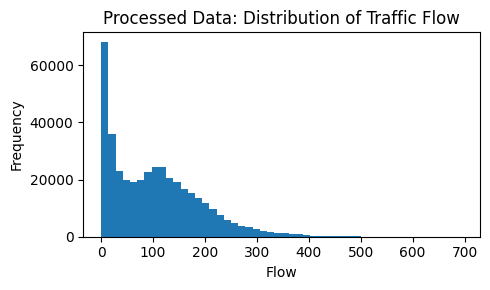

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3))
plt.hist(traffic_direction_timeseries["flow"], bins=50)
plt.title("Processed Data: Distribution of Traffic Flow")
plt.xlabel("Flow")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

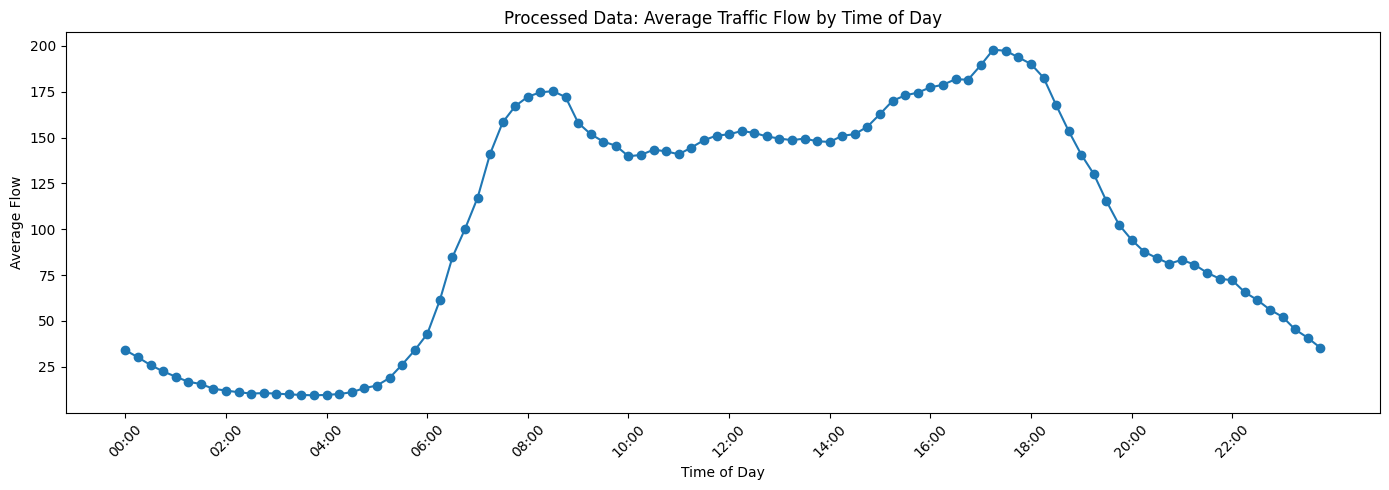

In [87]:
avg_by_interval = (
    traffic_direction_timeseries
    .groupby("interval")["flow"]
    .mean()
    .reset_index()
)

avg_by_interval["time_label"] = avg_by_interval["interval"].apply(
    lambda x: f"{(x * 15) // 60:02d}:{(x * 15) % 60:02d}"
)

plt.figure(figsize=(14, 5))
plt.plot(avg_by_interval["interval"], avg_by_interval["flow"], marker="o")
plt.xticks(
    avg_by_interval["interval"][::8],
    avg_by_interval["time_label"][::8],
    rotation=45
)
plt.title("Processed Data: Average Traffic Flow by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Average Flow")
plt.tight_layout()
plt.show()

Total site-direction coordinate records: 140
Valid coordinate records: 139
Invalid coordinate records: 1

Invalid coordinates found:


,site_id,scats_number,location,latitude,longitude
317856,4266,4266,AUBURN_RD_N_of_BURWOOD_RD,0.0,0.0


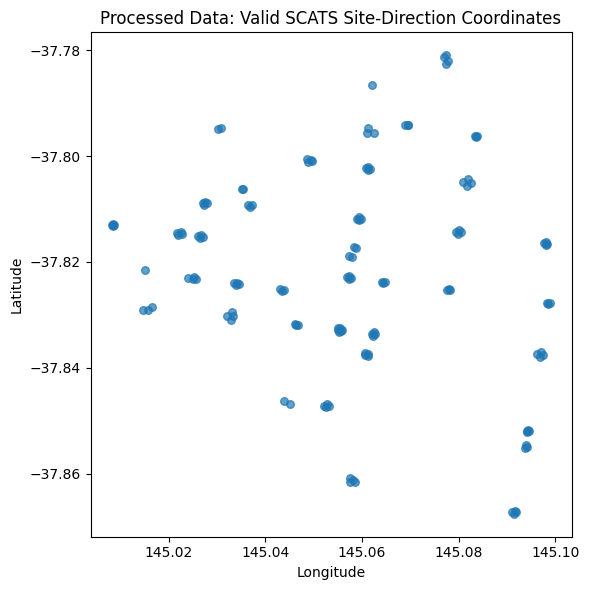

,site_id,scats_number,location,latitude,longitude
0,0970,0970,HIGH_STREET_RD_E_of_WARRIGAL_RD,-37.867350,145.091950
2976,0970,0970,HIGH_STREET_RD_W_of_WARRIGAL_RD,-37.867230,145.091030
5856,0970,0970,WARRIGAL_RD_N_of_HIGH_STREET_RD,-37.867030,145.091590
8832,0970,0970,WARRIGAL_RD_S_of_HIGH_STREET_RD,-37.867600,145.091460
11808,2000,2000,BURWOOD_HWY_E_of_WARRIGAL_RD,-37.851930,145.094630
14592,2000,2000,TOORAK_RD_W_of_WARRIGAL_RD,-37.851870,145.094070
17376,2000,2000,WARRIGAL_RD_N_of_TOORAK_RD,-37.851683,145.094346
20064,2000,2000,WARRIGAL_RD_S_of_BURWOOD_HWY,-37.852210,145.094250
22752,2200,2200,MAROONDAH_HWY_E_of_UNION_RD,-37.816550,145.098310
25728,2200,2200,MAROONDAH_HWY_W_of_UNION_RD,-37.816480,145.097739


In [88]:
# Visualise SCATS site-direction coordinates

from matplotlib.ticker import ScalarFormatter

# Make sure coordinate columns are numeric
traffic_direction_timeseries["latitude"] = pd.to_numeric(
    traffic_direction_timeseries["latitude"],
    errors="coerce"
)

traffic_direction_timeseries["longitude"] = pd.to_numeric(
    traffic_direction_timeseries["longitude"],
    errors="coerce"
)

site_coords = (
    traffic_direction_timeseries[
        ["site_id", "scats_number", "location", "latitude", "longitude"]
    ]
    .drop_duplicates()
    .sort_values(["site_id", "location"])
)

invalid_coords = site_coords[
    (site_coords["latitude"].isna()) |
    (site_coords["longitude"].isna()) |
    ((site_coords["latitude"] == 0) & (site_coords["longitude"] == 0))
]

valid_coords = site_coords[
    (site_coords["latitude"].notna()) &
    (site_coords["longitude"].notna()) &
    ~((site_coords["latitude"] == 0) & (site_coords["longitude"] == 0))
]

print("Total site-direction coordinate records:", len(site_coords))
print("Valid coordinate records:", len(valid_coords))
print("Invalid coordinate records:", len(invalid_coords))

if len(invalid_coords) > 0:
    print("\nInvalid coordinates found:")
    display(invalid_coords)

plt.figure(figsize=(6, 6))
plt.scatter(
    valid_coords["longitude"],
    valid_coords["latitude"],
    s=30,
    alpha=0.7
)

plt.title("Processed Data: Valid SCATS Site-Direction Coordinates")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Disable axis offset such as +1.45e2
ax = plt.gca()
ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.ticklabel_format(style="plain", axis="both")

plt.tight_layout()
plt.show()

display(valid_coords.head(20))

In [89]:
# Check one-way and two-way inferred edges

edge_pairs = set(zip(edges_df["from_site"], edges_df["to_site"]))

one_way_edges = []
two_way_edges = []

for from_site, to_site in edge_pairs:
    reverse_exists = (to_site, from_site) in edge_pairs
    
    if reverse_exists:
        two_way_edges.append((from_site, to_site))
    else:
        one_way_edges.append((from_site, to_site))

print("One-way inferred edges:", len(one_way_edges))
print("Two-way inferred edge records:", len(two_way_edges))

one_way_df = pd.DataFrame(one_way_edges, columns=["from_site", "to_site"])
display(one_way_df.head(44))

One-way inferred edges: 44
Two-way inferred edge records: 0


,from_site,to_site
0,4040,3120
1,3002,4035
2,3001,3002
3,3804,3682
4,4057,3180
5,4040,3812
6,3662,2820
7,4273,4043
8,4035,4034
9,4040,3804


Unique SCATS sites: 40
Unique site-directions with road/direction/flow: 138
Unique road names: 47


,site_id,location,latitude,longitude,flow,road_name,direction,reference_road
0,0970,HIGH_STREET_RD_E_of_WARRIGAL_RD,-37.86735,145.09195,99.530578,HIGH_STREET_RD,E,WARRIGAL_RD
1,0970,HIGH_STREET_RD_W_of_WARRIGAL_RD,-37.86723,145.09103,115.346528,HIGH_STREET_RD,W,WARRIGAL_RD
2,0970,WARRIGAL_RD_N_of_HIGH_STREET_RD,-37.86703,145.09159,188.850806,WARRIGAL_RD,N,HIGH_STREET_RD
3,0970,WARRIGAL_RD_S_of_HIGH_STREET_RD,-37.86760,145.09146,184.307460,WARRIGAL_RD,S,HIGH_STREET_RD
4,2000,BURWOOD_HWY_E_of_WARRIGAL_RD,-37.85193,145.09463,158.143319,BURWOOD_HWY,E,WARRIGAL_RD
...,...,...,...,...,...,...,...,...
133,4812,SWAN_ST_SW_of_MADDEN_GV,-37.82903,145.01456,84.933494,SWAN_ST,SW,MADDEN_GV
134,4821,BURNLEY_ST_S_OF_VICTORIA_ST,-37.81312,145.00844,70.747648,BURNLEY_ST,S,VICTORIA_ST
135,4821,VICTORIA_ST_E_OF_BURNLEY_ST,-37.81293,145.00865,129.391801,VICTORIA_ST,E,BURNLEY_ST
136,4821,VICTORIA_ST_W_OF_BURNLEY_ST,-37.81296,145.00830,127.036290,VICTORIA_ST,W,BURNLEY_ST


Inferred edges: 44


,from_site,to_site,road_name,from_location,to_location,from_direction,to_direction,mean_flow
0,3127,4063,BALWYN_RD,BALWYN_RD_N_of_CANTERBURY_RD,BALWYN_RD_N_OF_WHITEHORSE_RD,N,N,74.640948
1,4063,4057,BALWYN_RD,BALWYN_RD_N_OF_WHITEHORSE_RD,BALWYN_RD_N_OF_BELMORE_RD,N,N,80.992440
2,4057,3180,BALWYN_RD,BALWYN_RD_N_OF_BELMORE_RD,BALWYN_RD_S_of_DONCASTER_RD,N,S,75.801243
3,3001,3002,BARKERS_RD,BARKERS_RD_E_of_HIGH_ST,BARKERS_RD_E_of_DENMARK_ST,E,E,124.614351
4,3002,4035,BARKERS_RD,BARKERS_RD_E_of_DENMARK_ST,BARKERS_RD_W_of_BURKE_RD,E,W,109.354942
5,4032,4057,BELMORE_RD,BELMORE_RD_E_of_BURKE_RD,BELMORE_RD_E_OF_BALWYN_RD,E,E,75.032471
6,4043,4040,BURKE_RD,BURKE_RD_N_of_TOORAK_RD,BURKE_RD_N_of_RIVERSDALE_RD,N,N,111.392809
7,4040,3120,BURKE_RD,BURKE_RD_N_of_RIVERSDALE_RD,BURKE_RD_N_of_CANTERBURY_RD,N,N,112.496808
8,3120,4035,BURKE_RD,BURKE_RD_N_of_CANTERBURY_RD,BURKE_RD_N_of_MONT_ALBERT_RD,N,N,140.408770
9,4035,4034,BURKE_RD,BURKE_RD_N_of_MONT_ALBERT_RD,BURKE_RD_N_OF_WHITEHORSE_RD,N,N,144.846774


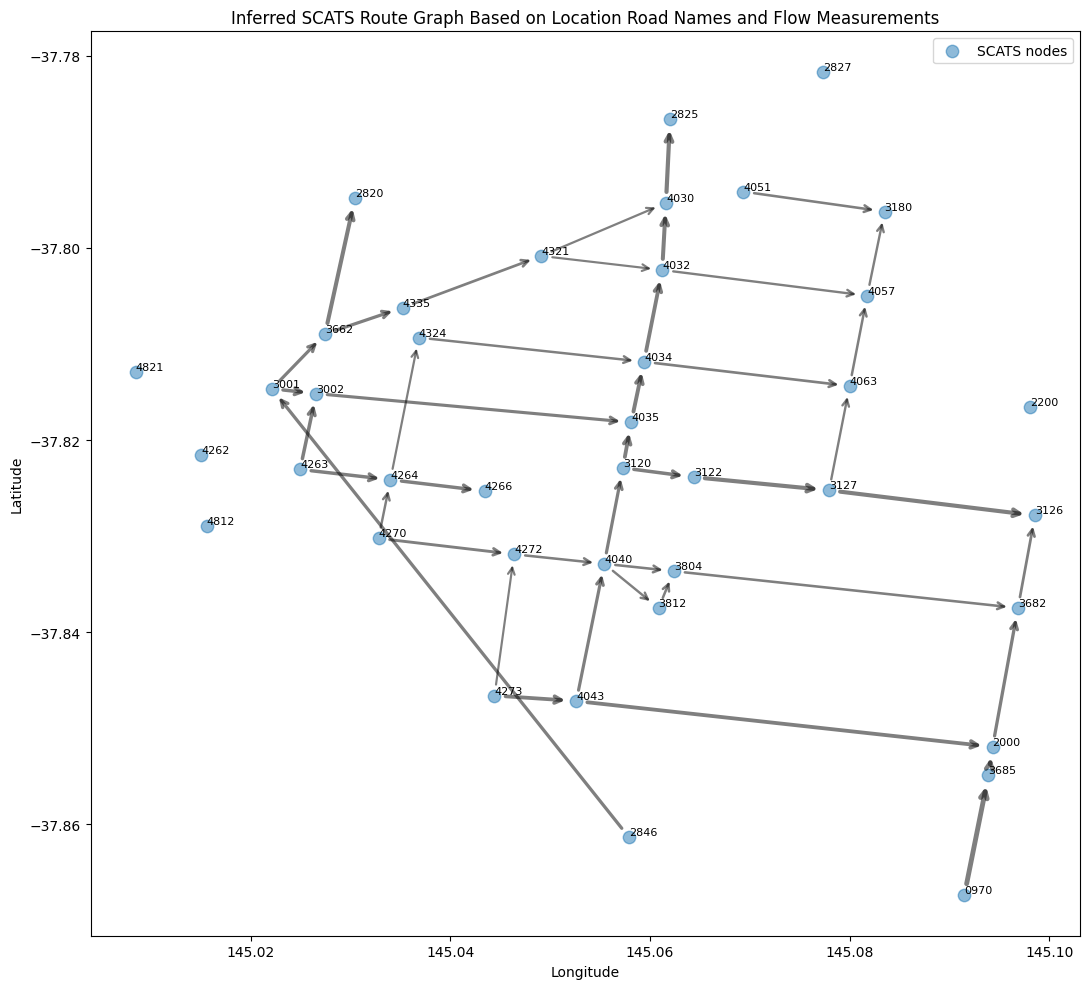

In [92]:
# Build and visualise an inferred SCATS route graph
# Conditions:
# 1. Two nodes are connected only if their location records share the same road/access name.
# 2. The site-direction must have traffic flow measurements
# 3. Strictly follow one-way inferred edges

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

df = traffic_direction_timeseries.copy()

# Make sure coordinate and flow columns are numeric
df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
df["flow"] = pd.to_numeric(df["flow"], errors="coerce")

# Remove only coordinate outliers from the map visualisation, not from the dataset
df_map = df[
    df["latitude"].notna()
    & df["longitude"].notna()
    & ~((df["latitude"] == 0) & (df["longitude"] == 0))
].copy()

# 1. Get unique site-direction records

site_directions = (
    df_map[["site_id", "location", "latitude", "longitude", "flow"]]
    .groupby(["site_id", "location"], as_index=False)
    .agg({
        "latitude": "mean",
        "longitude": "mean",
        "flow": "mean"
    })
)

# 2. Parse location text

def parse_location(location):
    text = str(location).strip().upper()
    text = text.replace(" ", "_")

    pattern = r"(.+?)_(NE|NW|SE|SW|N|S|E|W)_OF_(.+)"
    match = re.match(pattern, text)

    if match:
        road_name = match.group(1)
        direction = match.group(2)
        reference_road = match.group(3)
        return pd.Series([road_name, direction, reference_road])

    return pd.Series([None, None, None])

site_directions[["road_name", "direction", "reference_road"]] = (
    site_directions["location"].apply(parse_location)
)

# Keep only records that have road/direction info and flow measurement
site_directions_valid = site_directions[
    site_directions["road_name"].notna()
    & site_directions["direction"].notna()
    & site_directions["flow"].notna()
].copy()

print("Unique SCATS sites:", site_directions_valid["site_id"].nunique())
print("Unique site-directions with road/direction/flow:", len(site_directions_valid))
print("Unique road names:", site_directions_valid["road_name"].nunique())

display(site_directions_valid.head(1000))

# 3. Create node coordinates

nodes = (
    site_directions_valid
    .groupby("site_id", as_index=False)
    .agg({
        "latitude": "mean",
        "longitude": "mean"
    })
)

# 4. Infer edges

edges = []

for road_name, group in site_directions_valid.groupby("road_name"):
    group = group.drop_duplicates(subset=["site_id", "road_name"]).copy()

    if len(group) < 2:
        continue

    # Decide whether to sort mainly by longitude or latitude.
    # This is only for ordering nodes along the same road corridor.
    lon_range = group["longitude"].max() - group["longitude"].min()
    lat_range = group["latitude"].max() - group["latitude"].min()

    if lon_range >= lat_range:
        group = group.sort_values("longitude")
    else:
        group = group.sort_values("latitude")

    group = group.reset_index(drop=True)

    for i in range(len(group) - 1):
        a = group.iloc[i]
        b = group.iloc[i + 1]

        if a["site_id"] == b["site_id"]:
            continue

        edge_flow = np.mean([a["flow"], b["flow"]])

        edges.append({
            "from_site": a["site_id"],
            "to_site": b["site_id"],
            "road_name": road_name,
            "from_location": a["location"],
            "to_location": b["location"],
            "from_direction": a["direction"],
            "to_direction": b["direction"],
            "mean_flow": edge_flow
        })

edges_df = pd.DataFrame(edges).drop_duplicates(
    subset=["from_site", "to_site", "road_name"]
)

print("Inferred edges:", len(edges_df))
display(edges_df.head(1000))

# 5. Visualise nodes and inferred edges

plt.figure(figsize=(11, 10))
ax = plt.gca()

# Draw inferred edges
for _, edge in edges_df.iterrows():
    from_node = nodes[nodes["site_id"] == edge["from_site"]]
    to_node = nodes[nodes["site_id"] == edge["to_site"]]

    if from_node.empty or to_node.empty:
        continue

    x1 = from_node["longitude"].iloc[0]
    y1 = from_node["latitude"].iloc[0]
    x2 = to_node["longitude"].iloc[0]
    y2 = to_node["latitude"].iloc[0]

    # Line width based on mean flow, kept simple
    line_width = 0.5 + (edge["mean_flow"] / edges_df["mean_flow"].max()) * 3

    ax.annotate(
        "",
        xy=(x2, y2),          # arrow end
        xytext=(x1, y1),      # arrow start
        arrowprops=dict(
            arrowstyle="->",
            linewidth=line_width,
            alpha=0.5,
            shrinkA=8,
            shrinkB=8,
            mutation_scale=12
        )
    )

# Draw SCATS nodes
plt.scatter(
    nodes["longitude"],
    nodes["latitude"],
    s=80,
    alpha=0.5,
    label="SCATS nodes"
)

# Label nodes
for _, row in nodes.iterrows():
    plt.text(
        row["longitude"],
        row["latitude"],
        str(row["site_id"]),
        fontsize=8,
        ha="left",
        va="bottom"
    )

plt.title("Inferred SCATS Route Graph Based on Location Road Names and Flow Measurements")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Disable +1.45e2 axis offset
ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.ticklabel_format(style="plain", axis="both")

plt.legend()
plt.tight_layout()
plt.show()

## 12. Save processed data

The final output is:

`processed/traffic_direction_timeseries.csv`


In [91]:
traffic_direction_timeseries.to_csv(OUTPUT_FILE, index=False)

print("Saved processed file:")
print(OUTPUT_FILE)

saved_check = pd.read_csv(OUTPUT_FILE)
print("Saved file shape:", saved_check.shape)

Saved processed file:
/Users/truonghuuminhhai/Documents/COS30019/Assignment2B/cos30019_assignment2_b/data/processed/traffic_direction_timeseries.csv
Saved file shape: (402432, 9)
